# Atelier 7 — Fine-tuning ResNet18 sur CIFAR-10

## Imports

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import matplotlib.pyplot as plt
from tqdm import tqdm
from torch import nn
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Chargement de CIFAR-10

CIFAR-10 est un jeu de données de référence en apprentissage automatique, composé de 60 000 images couleur 32×32 pixels réparties en 10 classes (avion, voiture, oiseau, chat, cerf, chien, grenouille, cheval, bateau, camion).

ResNet18 a été entraîné sur **ImageNet** dont les images font 224×224 pixels. On applique donc deux transformations supplémentaires :
- `Resize(224)` : redimensionne les images 32×32 → 224×224
- `Normalize(mean, std)` : normalise avec les statistiques d'ImageNet pour que les entrées correspondent à ce qu'a vu le modèle pendant son pré-entraînement

In [2]:
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

train_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

print(f"Train samples: {len(train_dataset)}")
print(f"Test samples:  {len(test_dataset)}")
print(f"Image shape:   {train_dataset[0][0].shape}")
print(f"Classes:       {train_dataset.classes}")

Train samples: 50000
Test samples:  10000
Image shape:   torch.Size([3, 224, 224])
Classes:       ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


On visualise quelques exemples. Les images sont dénormalisées pour l'affichage.

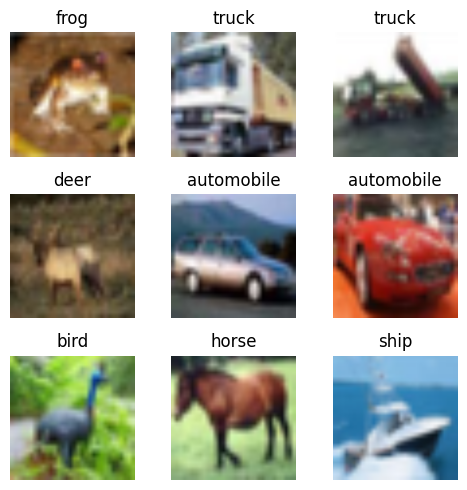

In [3]:
mean = torch.tensor(imagenet_mean).view(3, 1, 1)
std  = torch.tensor(imagenet_std).view(3, 1, 1)

fig, axes = plt.subplots(3, 3, figsize=(5, 5))
for i, ax in enumerate(axes.flat):
    img, label = train_dataset[i]
    img = (img * std + mean).clamp(0, 1)  # dénormalisation
    ax.imshow(img.permute(1, 2, 0))
    ax.set_title(train_dataset.classes[label])
    ax.axis('off')
plt.tight_layout()
plt.show()

### DataLoader

Le `DataLoader` est un itérateur qui découpe le dataset en **mini-batches** et les mélange à chaque époque (`shuffle=True` pour l'entraînement).  
Ici un batch contient 64 images, chacune de forme `[3, 224, 224]` → batch de forme `[64, 3, 224, 224]`.

In [4]:
train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_dataloader  = DataLoader(test_dataset,  batch_size=64, shuffle=False)

train_features, train_labels = next(iter(train_dataloader))
train_features.size()

torch.Size([64, 3, 224, 224])

## Fine-tuning du ResNet18

**ResNet18** est un CNN pré-entraîné sur ImageNet (1.2 million d'images, 1000 classes). Il a appris à reconnaître une grande variété de formes, textures et objets.

Le fine-tuning consiste à :
1. **Geler les couches convolutives** (`requires_grad = False`) : leurs poids ne seront pas mis à jour. Elles savent déjà extraire des features visuelles pertinentes.
2. **Remplacer la couche de sortie** (`fc`) : la tête originale prédit 1000 classes ImageNet. On la remplace par une couche `Linear(512 → 10)` pour nos 10 classes CIFAR-10.
3. **Entraîner uniquement la nouvelle tête** : seule cette couche a `requires_grad = True`.

```
ResNet18 (pré-entraîné ImageNet)
├── conv1, bn1, relu, maxpool      [gelés]
├── layer1  (2 blocs résiduels)    [gelés]
├── layer2  (2 blocs résiduels)    [gelés]
├── layer3  (2 blocs résiduels)    [gelés]
├── layer4  (2 blocs résiduels)    [gelés]
├── avgpool                        [gelé]
└── fc : Linear(512 → 10)          [entraînable ← remplacé]
```

In [5]:
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Geler toutes les couches
for param in resnet.parameters():
    param.requires_grad = False

# Remplacer la tête pour CIFAR-10 (10 classes)
resnet.fc = nn.Linear(512, 10)
resnet = resnet.to(device)

n_params_total      = sum(p.numel() for p in resnet.parameters())
n_params_trainable  = sum(p.numel() for p in resnet.parameters() if p.requires_grad)
print(f"Paramètres totaux      : {n_params_total:,}")
print(f"Paramètres entraînables: {n_params_trainable:,}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\arnau/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 97.5MB/s]


Paramètres totaux      : 11,181,642
Paramètres entraînables: 5,130


In [6]:
x_dummy = torch.randn(1, 3, 224, 224).to(device)
output = resnet(x_dummy)
print(f"Entrée : {x_dummy.shape} → Sortie : {output.shape}")
print(f"Scores : {output}")

Entrée : torch.Size([1, 3, 224, 224]) → Sortie : torch.Size([1, 10])
Scores : tensor([[-0.0353,  0.1589,  0.2271, -0.0899, -0.9211, -0.0820, -0.4178, -0.0209,
          0.4931,  0.0393]], device='cuda:0', grad_fn=<AddmmBackward0>)


## Entraînement

L'entraînement repose sur deux éléments :

- **Fonction de perte** (`CrossEntropyLoss`) : mesure l'écart entre la prédiction du modèle et la vraie étiquette.
- **Optimiseur** (`AdamW`, lr=0.001) : met à jour **uniquement les poids de la couche `fc`**, car ce sont les seuls avec `requires_grad = True`.

À chaque **époque** :
1. `train_loop` — le modèle apprend en ajustant la tête de classification
2. `test_loop` — le modèle est évalué sans mise à jour des poids (`torch.no_grad()`)

In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(resnet.fc.parameters(), lr=1e-3)

In [8]:
def train_loop(dataloader, model, loss_fn, optimizer, writer, epoch):
    model.train()
    pbar = tqdm(dataloader, desc="Train")
    for batch, (x, y_true) in enumerate(pbar):
        x, y_true = x.to(device), y_true.to(device)
        y_pred = model(x)
        loss = loss_fn(y_pred, y_true)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        pbar.set_postfix(loss=f"{loss.item():.4f}")
        writer.add_scalar("Loss/train", loss.item(), epoch * len(dataloader) + batch)

def test_loop(dataloader, model, loss_fn, writer, epoch):
    model.eval()
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, correct = 0, 0

    with torch.no_grad():
        for x, y_true in tqdm(dataloader, desc="Test "):
            x, y_true = x.to(device), y_true.to(device)
            y_pred = model(x)
            test_loss += loss_fn(y_pred, y_true).item()
            correct += (y_pred.argmax(1) == y_true).type(torch.float).sum().item()

    test_loss /= num_batches
    correct /= size
    print(f"Accuracy: {100 * correct:>0.1f}%, Avg loss: {test_loss:.6f}")

    writer.add_scalar("Loss/test", test_loss, epoch)
    writer.add_scalar("Accuracy/test", 100 * correct, epoch)

In [9]:
writer = SummaryWriter("runs/resnet18_cifar10")

epochs = 5

for t in range(epochs):
    print(f"Epoch : {t+1}")
    train_loop(train_dataloader, resnet, criterion, optimizer, writer, t)
    test_loop(test_dataloader, resnet, criterion, writer, t)

writer.close()
print("Done")

Epoch : 1


Test : 100%|██████████| 157/157 [00:09<00:00, 16.02it/s]


Accuracy: 78.5%, Avg loss: 0.635626
Epoch : 2


Test : 100%|██████████| 157/157 [00:09<00:00, 16.54it/s]


Accuracy: 79.1%, Avg loss: 0.607722
Epoch : 3


...

Accuracy: 80.1%, Avg loss: 0.585748
Epoch : 4


Test : 100%|██████████| 157/157 [00:09<00:00, 16.36it/s]


Accuracy: 80.0%, Avg loss: 0.578059
Epoch : 5


Test : 100%|██████████| 157/157 [00:09<00:00, 16.44it/s]

Accuracy: 79.7%, Avg loss: 0.588687
Done
